## DATASET SELECTION AND UNDERSTANDING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### CHOOSEN DATASET

Dataset used: AI4I 2020 Predictive Maintenance Dataset
- Description:
1. The predictive maintenance dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry.
2. The dataset consisting of 10000 data points as rows stored with 14 features in columns.
3. The dataset is obtained from UC Irvine Machine Learning Respository, linked: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
4. Machine Failure: {0: 'Good', 1: 'Fail'}

In [20]:
df = pd.read_csv("../data/ai4i2020.csv")

### DATASET DESCRIPTION

In [21]:
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [28]:
df.shape
print(f"The dataset consist of {df.shape[0]} rows, {df.shape[1]} columns")

The dataset consist of 10000 rows, 14 columns


In [31]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [43]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

### CLEANING AND PREPROCESSING

In [54]:
df = df.drop(columns=['UDI', 'Product ID','TWF','HDF','PWF','OSF','RNF'])

Justification to remove the duplicates:
1. UDI and Product ID is list of ID number for the machinery which irrelevant to use for training.
2. TWF, HDF, PWF, OSF, RNF is specific failure type. It will cause data leakage if used, since if either one failure type equalls to 1, it automatically make 'Machine Failure' status to 1. Meaning if included in the training, the model will look at these columns to answer instead of learning from the sensor inputs (temperature, torque, and speed).
3. If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1.

In [108]:
# Check available columns
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [114]:
# Rename column for standardization, 1st letter of word must be capital
df = df.rename(columns={
    'Air temperature [K]': 'Air Temperature [K]',
    'Process temperature [K]': 'Process Temperature [K]',
    'Rotational speed [rpm]': 'Rotational Speed [rpm]',
    'Tool wear [min]': 'Tool Wear [min]',
    'Machine failure': 'Machine Failure'
})

In [115]:
# Check renamed columns
df.columns

Index(['Type', 'Air Temperature [K]', 'Process Temperature [K]',
       'Rotational Speed [rpm]', 'Torque [Nm]', 'Tool Wear [min]',
       'Machine Failure'],
      dtype='object')

In [ ]:
# Check for duplicated rows
print(f"Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


In [113]:
# Count number of rows in each columns
df.count()

Type                       10000
Air Temperature [K]        10000
Process Temperature [K]    10000
Rotational Speed [rpm]     10000
Torque [Nm]                10000
Tool Wear [min]            10000
Machine Failure            10000
dtype: int64

In [116]:
# Check for missing or null values
print(df.isnull().sum())

Type                       0
Air Temperature [K]        0
Process Temperature [K]    0
Rotational Speed [rpm]     0
Torque [Nm]                0
Tool Wear [min]            0
Machine Failure            0
dtype: int64


From the result above, this dataset does not has:
1. Duplicate.
2. Missing Values.
3. Null

### EXPLORATORY DATA ANALYSIS

BOXPLOT

<Axes: xlabel='Tool Wear [min]'>

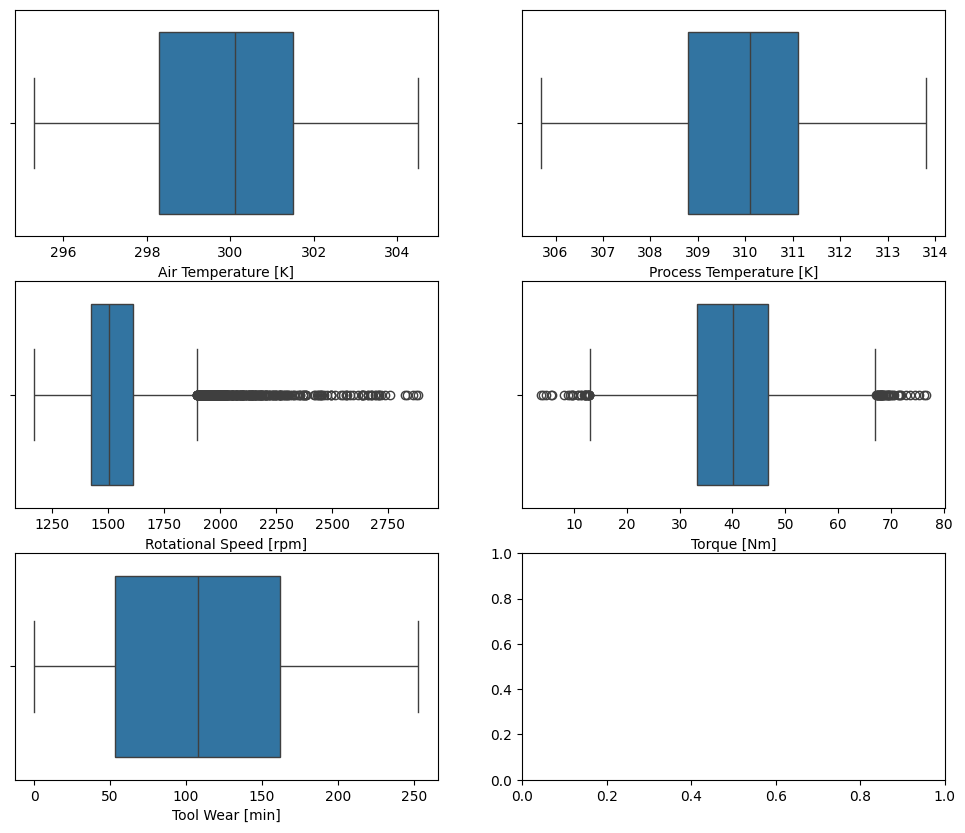

In [117]:
# BOXPLOT to DETECT OUTLIER
fix, axes = plt.subplots(3,2, figsize=(12,10))
sns.boxplot(ax=axes[0,0], data=df, x='Air Temperature [K]')
sns.boxplot(ax=axes[0,1], data=df, x='Process Temperature [K]')
sns.boxplot(ax=axes[1,0], data=df, x='Rotational Speed [rpm]') 
sns.boxplot(ax=axes[1,1], data=df, x='Torque [Nm]')
sns.boxplot(ax=axes[2,0], data=df, x='Tool Wear [min]')

Explanation:
From the boxplot produced, while outliers are detected in 'Rotational Speed [rpm]' and 'Torque [Nm]', this value is to be retained in the dataset as the extreme value can be an indicated as operational anomalies that are hypothesized to be primary drivers of machine failure. 


HEATMAP

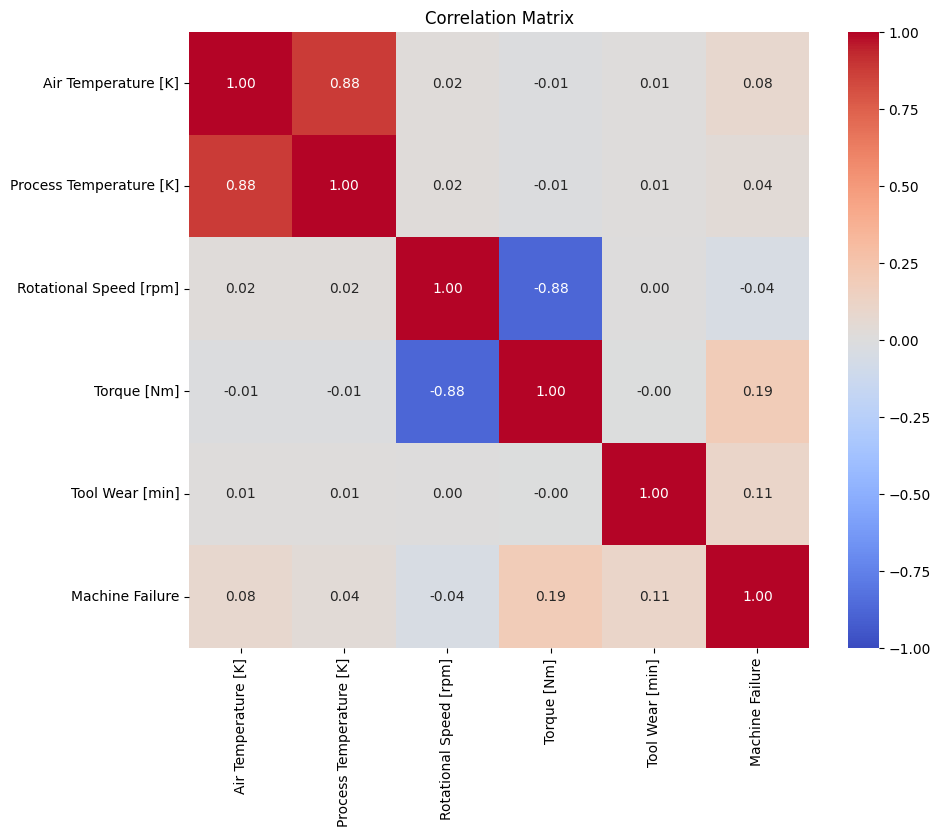

In [118]:
plt.figure(figsize=(10, 8))

num_columns = ['Air Temperature [K]', 
                'Process Temperature [K]', 
                'Rotational Speed [rpm]',
                'Torque [Nm]',
                'Tool Wear [min]',
                'Machine Failure']
corr_matrix = df[num_columns].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

Explanation:
1. It can be observed that 'Air Temperature [K]' and closely related with 'Process Temperature [K]' with each correleation coefficient of 0.88. It can be concluded if air temperature increases, process temperature increase.
2. There are negative correlation between 'Rotational speed [rpm]' and 'Torque [Nm]', which shows when speed goes up, torque goes down. When the machine hits resistance because of torque spike, speed drops.
3. While there are no correleation observed between 'Machine failure' and other variables it does not indicate is it redundant, but because the heatmap utilizes 'Pearson correlation', which evaluates whether variables follows a straight line based on formula, y=mx+c. 'Machine failure' does not behave linearly.

PAIRPLOT

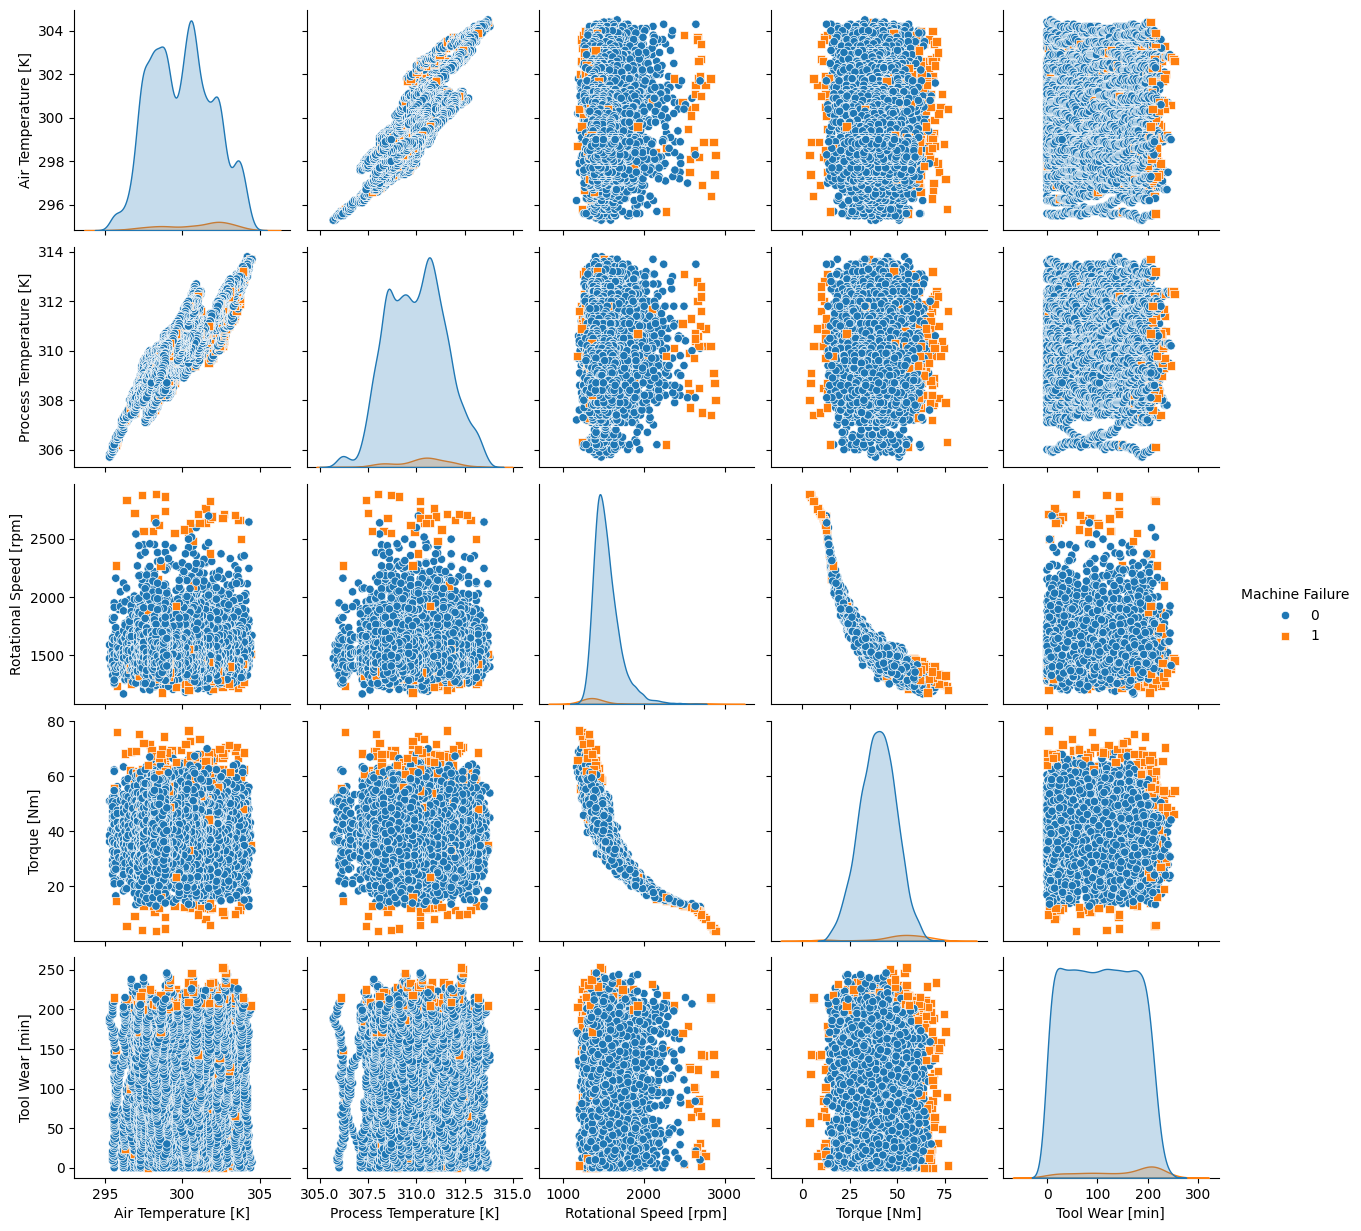

In [ ]:
sns.pairplot(df, hue='Machine Failure', markers=["o", "s"])

From the scatter plot produce:

1. From observation, 'Machine Failure' occur both when the 'Air Temperature [K]' and 'Process Temperature [K]' either at their highest or at their lowest.
2. The chances for 'Machine Failure' to occur is either when the value Rotational Speed [rpm] or Torque[Nm] at its highest or at its lowest. It informes us that 'Machine Failure' can occur at the highest rotational speed at lowest torque, or lowest speed at highest torque.